In [1]:
!pip install supervision 

In [ ]:
import pandas as pd 
import numpy as np 

In [60]:
!pip install "ultralytics<=8.3.40"


   ---------------------------------------- 0.0/898.5 kB ? eta -:--:--
   --------------------------------------- 898.5/898.5 kB 20.5 MB/s eta 0:00:00
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.3.71
    Uninstalling ultralytics-8.3.71:
      Successfully uninstalled ultralytics-8.3.71


In [2]:
import torch
!nvcc --version
TORCH_VERSION = ".".join(torch.__version__.split(".")[:2])
CUDA_VERSION = torch.__version__.split("+")[-1]
print("torch: ", TORCH_VERSION, "; cuda: ", CUDA_VERSION)

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2022 NVIDIA Corporation
Built on Wed_Sep_21_10:41:10_Pacific_Daylight_Time_2022
Cuda compilation tools, release 11.8, V11.8.89
Build cuda_11.8.r11.8/compiler.31833905_0
torch:  2.6 ; cuda:  cu118


In [3]:
!pip show ultralytics

Name: ultralytics
Version: 8.3.71
Summary: Ultralytics YOLO 🚀 for SOTA object detection, multi-object tracking, instance segmentation, pose estimation and image classification.
Home-page: https://ultralytics.com
Author: 
Author-email: Glenn Jocher <glenn.jocher@ultralytics.com>, Jing Qiu <jing.qiu@ultralytics.com>
License: AGPL-3.0
Location: c:\users\user\.conda\envs\env\lib\site-packages
Requires: matplotlib, numpy, opencv-python, pandas, pillow, psutil, py-cpuinfo, pyyaml, requests, scipy, seaborn, torch, torchvision, tqdm, ultralytics-thop
Required-by: 


In [6]:
import supervision as sv
print("supervision", sv.__version__)
!pip install supervision[assets] -q

from IPython import display
display.clear_output()

In [83]:
import torch

model = torch.hub.load('ultralytics/yolov5', 'yolov5x6')

Using cache found in C:\Users\user/.cache\torch\hub\ultralytics_yolov5_master
YOLOv5  2025-1-17 Python-3.10.16 torch-2.6.0+cu118 CUDA:0 (NVIDIA GeForce RTX 3080 Ti, 12288MiB)

Fusing layers... 
YOLOv5x6 summary: 574 layers, 140730220 parameters, 0 gradients, 209.6 GFLOPs
Adding AutoShape... 


In [9]:
from supervision.assets import download_assets, VideoAssets
from IPython import display


download_assets(VideoAssets.MARKET_SQUARE)
#download_assets(VideoAssets.GROCERY_STORE)
#download_assets(VideoAssets.SUBWAY)


display.clear_output()

In [84]:
VideoAssets.MARKET_SQUARE.value

'market-square.mp4'

SupervisionWarnings: BoundingBoxAnnotator is deprecated: `BoundingBoxAnnotator` is deprecated and has been renamed to `BoxAnnotator`. `BoundingBoxAnnotator` will be removed in supervision-0.26.0.


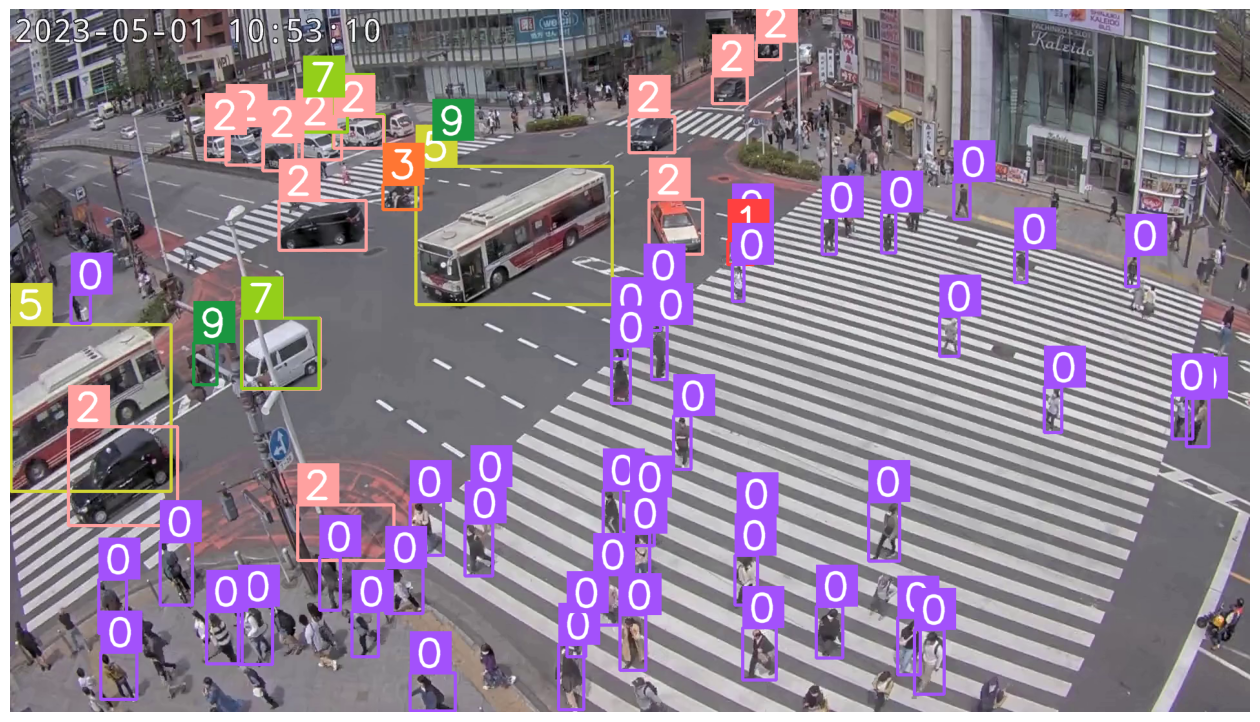

In [14]:
import supervision as sv

# extract video frame
video_path= r"C:\Users\user\Downloads\gente_muestra.mp4"
generator = sv.get_video_frames_generator(video_path)
iterator = iter(generator)
frame = next(iterator)

# detect
results = model(frame, size=1280)
detections = sv.Detections.from_yolov5(results)

# annotate
box_annotator = sv.BoundingBoxAnnotator(thickness=4)
label_annotator = sv.LabelAnnotator(text_thickness=4, text_scale=2)
frame = box_annotator.annotate(scene=frame, detections=detections)
frame = label_annotator.annotate(scene=frame, detections=detections)

%matplotlib inline
sv.plot_image(frame, (16, 16))

SupervisionWarnings: BoundingBoxAnnotator is deprecated: `BoundingBoxAnnotator` is deprecated and has been renamed to `BoxAnnotator`. `BoundingBoxAnnotator` will be removed in supervision-0.26.0.


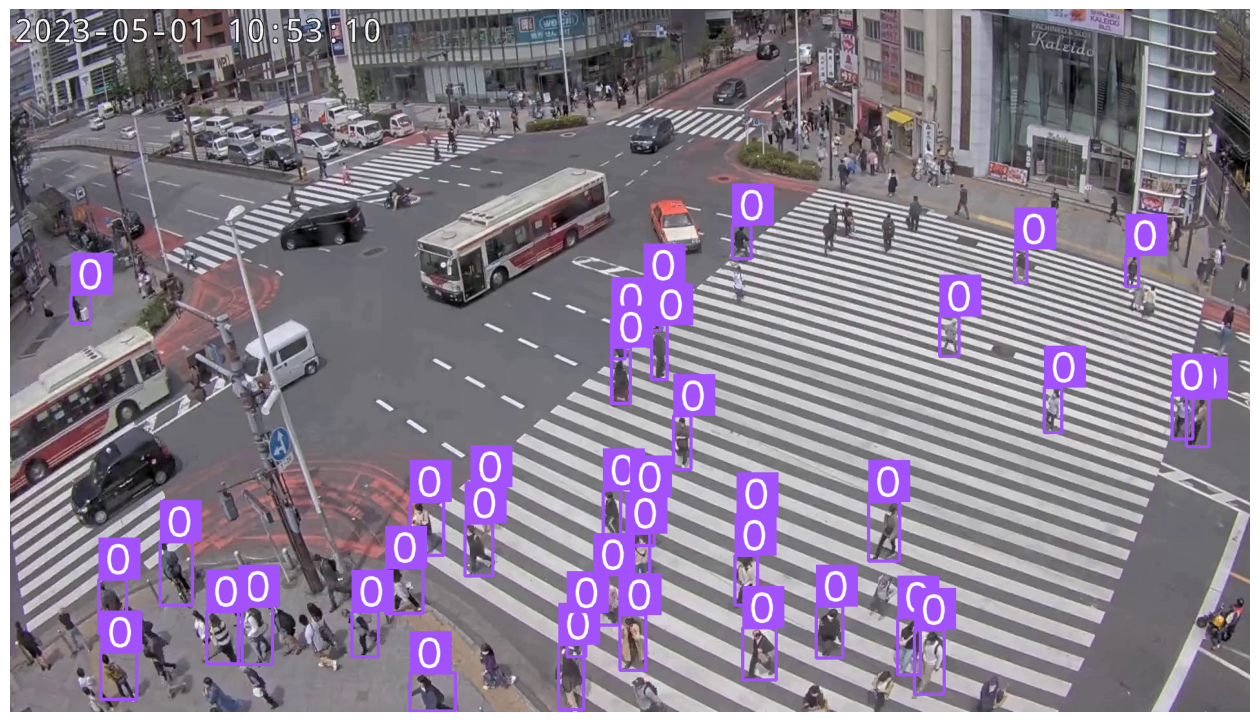

In [19]:
import supervision as sv

# extract video frame
generator = sv.get_video_frames_generator(video_path)
iterator = iter(generator)
frame = next(iterator)

# detect
results = model(frame, size=1280)
detections = sv.Detections.from_yolov5(results)
detections = detections[(detections.class_id == 0) & (detections.confidence > 0.3)]

# annotate
box_annotator = sv.BoundingBoxAnnotator(thickness=4)
label_annotator = sv.LabelAnnotator(text_thickness=4, text_scale=2)
frame = box_annotator.annotate(scene=frame, detections=detections)
frame = label_annotator.annotate(scene=frame, detections=detections)

%matplotlib inline
sv.plot_image(frame, (16, 16))

SupervisionWarnings: BoundingBoxAnnotator is deprecated: `BoundingBoxAnnotator` is deprecated and has been renamed to `BoxAnnotator`. `BoundingBoxAnnotator` will be removed in supervision-0.26.0.


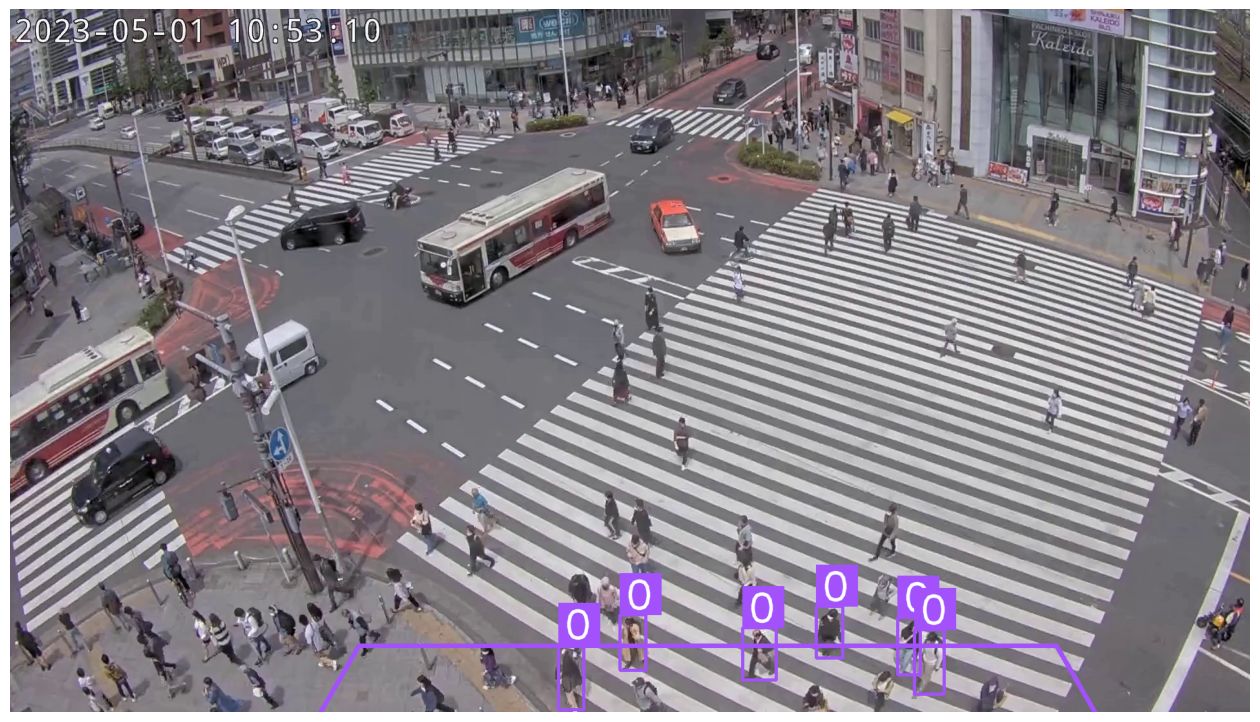

In [85]:
import numpy as np
import supervision as sv

# initiate polygon zone
polygon = np.array([
    [540,  985],
    [1620, 985],
    [2160, 1920],
    [1620, 2855],
    [540,  2855],
    [0,    1920]
])
video_info = sv.VideoInfo.from_video_path(video_path)
zone = sv.PolygonZone(polygon=polygon)

# extract video frame
generator = sv.get_video_frames_generator(video_path)
iterator = iter(generator)
frame = next(iterator)

# detect
results = model(frame, size=1280)
detections = sv.Detections.from_yolov5(results)
mask = zone.trigger(detections=detections)
detections = detections[(detections.class_id == 0) & (detections.confidence > 0.5) & mask]

# annotate
box_annotator = sv.BoundingBoxAnnotator(thickness=4)
label_annotator = sv.LabelAnnotator(text_thickness=4, text_scale=2)
frame = box_annotator.annotate(scene=frame, detections=detections)
frame = label_annotator.annotate(scene=frame, detections=detections)
frame = sv.draw_polygon(scene=frame, polygon=polygon, color=sv.Color.ROBOFLOW, thickness=6)

%matplotlib inline
sv.plot_image(frame, (16, 16))

SupervisionWarnings: BoundingBoxAnnotator is deprecated: `BoundingBoxAnnotator` is deprecated and has been renamed to `BoxAnnotator`. `BoundingBoxAnnotator` will be removed in supervision-0.26.0.
SupervisionWarnings: BoundingBoxAnnotator is deprecated: `BoundingBoxAnnotator` is deprecated and has been renamed to `BoxAnnotator`. `BoundingBoxAnnotator` will be removed in supervision-0.26.0.
SupervisionWarnings: BoundingBoxAnnotator is deprecated: `BoundingBoxAnnotator` is deprecated and has been renamed to `BoxAnnotator`. `BoundingBoxAnnotator` will be removed in supervision-0.26.0.
SupervisionWarnings: BoundingBoxAnnotator is deprecated: `BoundingBoxAnnotator` is deprecated and has been renamed to `BoxAnnotator`. `BoundingBoxAnnotator` will be removed in supervision-0.26.0.


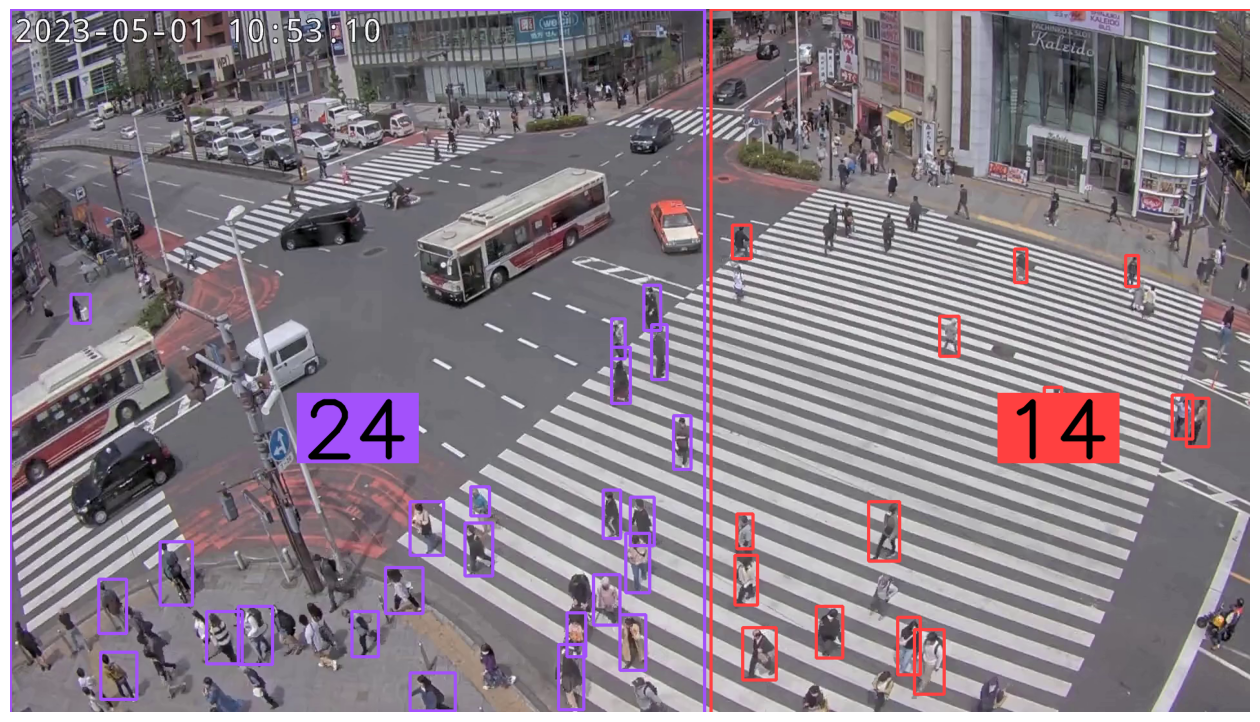

In [31]:
colors = sv.ColorPalette.DEFAULT
polygons = [
    np.array([
        [0, 0],
        [1080 - 5, 0],
        [1080 - 5, 1300 - 5],
        [0, 1300 - 5]
    ], np.int32),
    np.array([
        [1080 + 5, 0],
        [2160, 0],
        [2160, 1300 - 5],
        [1080 + 5, 1300 - 5]
    ], np.int32),
    np.array([
        [0, 1300 + 5],
        [1080 - 5, 1300 + 5],
        [1080 - 5, 3840],
        [0, 3840]
    ], np.int32),
    np.array([
        [1080 + 5, 1300 + 5],
        [2160, 1300 + 5],
        [2160, 3840],
        [1080 + 5, 3840]
    ], np.int32)
]
video_info = sv.VideoInfo.from_video_path(video_path)

zones = [sv.PolygonZone(polygon=polygon) for polygon in polygons]
zone_annotators = [
    sv.PolygonZoneAnnotator(
        zone=zone,
        color=colors.by_idx(index),
        thickness=4,
        text_thickness=8,
        text_scale=4
    )
    for index, zone
    in enumerate(zones)
]
box_annotators = [
    sv.BoundingBoxAnnotator(
        color=colors.by_idx(index),
        thickness=4,
    )
    for index
    in range(len(polygons))
]

# extract video frame
generator = sv.get_video_frames_generator(video_path)
iterator = iter(generator)
frame = next(iterator)

# detect
results = model(frame, size=1280)
detections = sv.Detections.from_yolov5(results)
detections = detections[(detections.class_id == 0) & (detections.confidence > 0.3)]

for zone, zone_annotator, box_annotator in zip(zones, zone_annotators, box_annotators):
    mask = zone.trigger(detections=detections)
    detections_filtered = detections[mask]
    frame = box_annotator.annotate(scene=frame, detections=detections_filtered)
    frame = zone_annotator.annotate(scene=frame)

%matplotlib inline
sv.plot_image(frame, (16, 16))

In [87]:
colors = sv.ColorPalette.DEFAULT
polygons = [
    np.array([
        [540,  985 ],
        [1620, 985 ],
        [2160, 1920],
        [1620, 2855],
        [540,  2855],
        [0,    1920]
    ], np.int32),
    np.array([
        [0,    1920],
        [540,  985 ],
        [0,    0   ]
    ], np.int32),
    np.array([
        [1620, 985 ],
        [2160, 1920],
        [2160,    0]
    ], np.int32),
    np.array([
        [540,  985 ],
        [0,    0   ],
        [2160, 0   ],
        [1620, 985 ]
    ], np.int32),
    np.array([
        [0,    1920],
        [0,    3840],
        [540,  2855]
    ], np.int32),
    np.array([
        [2160, 1920],
        [1620, 2855],
        [2160, 3840]
    ], np.int32),
    np.array([
        [1620, 2855],
        [540,  2855],
        [0,    3840],
        [2160, 3840]
    ], np.int32)
]
video_info = sv.VideoInfo.from_video_path(video_path)

zones = [sv.PolygonZone(polygon=polygon) for polygon in polygons]
zone_annotators = [
    sv.PolygonZoneAnnotator(
        zone=zone,
        color=colors.by_idx(index),
        thickness=6,
        text_thickness=8,
        text_scale=4
    )
    for index, zone
    in enumerate(zones)
]
box_annotators = [
    sv.BoundingBoxAnnotator(
        color=colors.by_idx(index),
        thickness=4,
    )
    for index
    in range(len(polygons))
]

def process_frame(frame: np.ndarray, i) -> np.ndarray:
    # detect
    results = model(frame, size=1280)
    detections = sv.Detections.from_yolov5(results)
    detections = detections[(detections.class_id == 0) & (detections.confidence > 0.3)]

    for zone, zone_annotator, box_annotator in zip(zones, zone_annotators, box_annotators):
        mask = zone.trigger(detections=detections)
        detections_filtered = detections[mask]
        frame = box_annotator.annotate(scene=frame, detections=detections_filtered)
        frame = zone_annotator.annotate(scene=frame)

    return frame

sv.process_video(source_path=video_path, target_path=f"market-square-result2.mp4", callback=process_frame)

from IPython import display
display.clear_output()

In [36]:
import supervision as sv
tracker = sv.ByteTrack()
print("Importación exitosa")

Importación exitosa


In [91]:
import supervision as sv
from ultralytics import YOLO
import numpy as np
import torch 
# Inicializar el modelo YOLO y ByteTrack
model = torch.hub.load('ultralytics/yolov5', 'yolov5x6') # Reemplaza <MODEL_PATH> con la ruta de tu modelo
tracker = sv.ByteTrack()  # Instancia del tracker ByteTrack <button class="citation-flag" data-index="3">
box_annotator = sv.BoxAnnotator()  # Anotador de cajas


# Definir colores y polígonos como en tu código original
colors = sv.ColorPalette.DEFAULT
polygons = [
    np.array([[540, 985], [1620, 985], [2160, 1920], [1620, 2855], [540, 2855], [0, 1920]], np.int32),
    np.array([[0, 1920], [540, 985], [0, 0]], np.int32),
    np.array([[1620, 985], [2160, 1920], [2160, 0]], np.int32),
    np.array([[540, 985], [0, 0], [2160, 0], [1620, 985]], np.int32),
    np.array([[0, 1920], [0, 3840], [540, 2855]], np.int32),
    np.array([[2160, 1920], [1620, 2855], [2160, 3840]], np.int32),
    np.array([[1620, 2855], [540, 2855], [0, 3840], [2160, 3840]], np.int32)
]
video_path= r"C:\Users\user\Downloads\gente_muestra.mp4"
# Información del video y zonas poligonales
video_info = sv.VideoInfo.from_video_path(video_path)
zones = [sv.PolygonZone(polygon=polygon) for polygon in polygons]
zone_annotators = [
    sv.PolygonZoneAnnotator(
        zone=zone,
        color=colors.by_idx(index),
        thickness=6,
        text_thickness=8,
        text_scale=4
    )
    for index, zone in enumerate(zones)
]

# Procesamiento de cada fotograma
def callback(frame: np.ndarray, index: int) -> np.ndarray:
    # Detectar objetos con YOLO
    results = model(frame)
    detections = sv.Detections.from_yolov5(results)
    
    # Filtrar detecciones por confianza (opcional)
    detections = detections[detections.confidence > 0.3]
    
    # Aplicar ByteTrack para seguimiento
    detections = tracker.update_with_detections(detections)
    
    # Generar etiquetas con IDs de seguimiento, clase y confianza
    labels = [
        f"#{tracker_id} {model.model.names[class_id]} {confidence:.2f}"
        for _, _, confidence, class_id, tracker_id in detections
    ]
    
    # Anotar cuadros delimitadores
    annotated_frame = box_annotator.annotate(
        scene=frame.copy(),
        detections=detections,
        labels=labels
        
    )
    
    

    
    return annotated_frame

# Procesar el video
sv.process_video(source_path=video_path, target_path=f"market-square-result2.mp4", callback=process_frame)

Using cache found in C:\Users\user/.cache\torch\hub\ultralytics_yolov5_master
YOLOv5  2025-1-17 Python-3.10.16 torch-2.6.0+cu118 CUDA:0 (NVIDIA GeForce RTX 3080 Ti, 12288MiB)

Fusing layers... 
YOLOv5x6 summary: 574 layers, 140730220 parameters, 0 gradients, 209.6 GFLOPs
Adding AutoShape... 


In [49]:
def callback(frame: np.ndarray, index: int) -> np.ndarray:
    results = model(frame)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = byte_tracker.update_with_detections(detections)
    labels = [
        f"#{tracker_id} {model.model.names[class_id]} {confidence:0.2f}"
       for _, _, confidence, class_id, tracker_id
      in detections
   ]
    return annotator.annotate(scene=frame.copy(), detections=detections, labels=labels)

In [89]:
def callback(frame: np.ndarray, index: int) -> np.ndarray:
    results = model(frame)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = byte_tracker.update_with_detections(detections)
    labels = [
        f"#{tracker_id} {model.model.names[class_id]} {confidence:0.2f}"
       for _, _, confidence, class_id, tracker_id
      in detections
   ]
    return annotator.annotate(scene=frame.copy(), detections=detections, labels=labels)

def process_frame(frame: np.ndarray, i) -> np.ndarray:
    # detect
    results = model(frame, size=1280)
    detections = sv.Detections.from_yolov5(results)
    detections = detections[(detections.class_id == 0) & (detections.confidence > 0.5)]

    for zone, zone_annotator, box_annotator in zip(zones, zone_annotators, box_annotators):
        mask = zone.trigger(detections=detections)
        detections_filtered = detections[mask]
        frame = box_annotator.annotate(scene=frame, detections=detections_filtered)
        frame = zone_annotator.annotate(scene=frame)

    return frame

In [86]:
!python --version

Python 3.10.16
